In [ ]:
#import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from PyEMD import EMD  # pip install PyEMD


# DATC Functions

In [2]:
def estimate_period_fft(series, default_period=24):
    """
    FFT를 활용하여 시계열 데이터에서 가장 지배적인 주기를 동적으로 추정합니다.
    """
    n = len(series)
    t = np.arange(n)
    
    # 1. FFT 전처리: 선형 추세 및 평균(DC 성분) 제거
    p = np.polyfit(t, series, 1)
    detrended = series - np.polyval(p, t)
    detrended = detrended - np.mean(detrended)
    
    # 2. FFT 수행 및 진폭 계산
    fft_vals = np.fft.rfft(detrended)
    frequencies = np.fft.rfftfreq(n)
    magnitudes = np.abs(fft_vals)
    
    # 3. 0Hz(상수항)를 제외하고 진폭이 가장 큰 인덱스 탐색
    if len(magnitudes) > 1:
        dominant_idx = np.argmax(magnitudes[1:]) + 1 
        dominant_freq = frequencies[dominant_idx]
        
        if dominant_freq > 0:
            period = int(np.round(1.0 / dominant_freq))
            if 2 <= period <= n // 2:
                return period
                
    return default_period

def calculate_time_series_strength(series, dec_method='stl_emd'):
    """
    FFT 기반 동적 주기 추출 후, 지정된 분해 방법론(dec_method)에 따라
    독립적 신호 대 잡음비(SNR) 기반의 F_T, F_S, F_I 지표를 산출합니다.
    
    Parameters:
    - series: 입력 시계열 데이터 (1D array-like)
    - dec_method: 'stl' (고전 STL 분해) 또는 'stl_emd' (STL-EMD 결합 분해)
    """
    estimated_p = estimate_period_fft(series)
    
    if len(series) < 2 * estimated_p:
        estimated_p = max(2, len(series) // 2 - 1)
        
    try:
        # 1. 공통 단계: STL 분해 (T, S, R_stl 도출)
        res = STL(series, period=estimated_p, robust=True).fit()
        T, S, R_stl = res.trend, res.seasonal, res.resid
        
        # 2. 분해 기법(dec_method)에 따른 분기 처리
        if dec_method == 'stl_emd':
            # EMD 분해 (Residual을 다시 분해하여 Intervention 추출)
            emd = EMD()
            imfs = emd.emd(R_stl)
            
            # IMF 성분 중 노이즈(IMF1)와 최저주파 잔차를 제외한 중간 대역을 I(Intervention)로 정의
            if len(imfs) > 2:
                I = np.sum(imfs[1:], axis=0) 
            elif len(imfs) == 2:
                I = imfs[1]
            else:
                I = np.zeros_like(R_stl)
                
            # 순수 노이즈(R_pure) = STL 잔차에서 개입 성분(I)을 제거한 청정 구역
            R_pure = R_stl - I
            
        elif dec_method == 'stl':
            # 고전적 STL: 개입 성분이 존재하지 않음 (I = 0)
            I = np.zeros_like(R_stl)
            # STL의 잔차가 곧 순수 노이즈로 간주됨
            R_pure = R_stl
            
        else:
            raise ValueError(f"Unknown dec_method: {dec_method}. Choose 'stl' or 'stl_emd'.")
            
        # 3. Hyndman 공리 기반의 성분별 직교(Orthogonal) 강도 계산
        var_R = np.var(R_pure)
        var_TR = np.var(T + R_pure) 
        var_SR = np.var(S + R_pure)
        var_IR = np.var(I + R_pure) 
        
        F_T = max(0.0, 1.0 - (var_R / var_TR if var_TR > 0 else 1.0))
        F_S = max(0.0, 1.0 - (var_R / var_SR if var_SR > 0 else 1.0))
        
        # dec_method='stl'일 경우 var_R == var_IR이 되므로 수리적으로 F_I는 자연스럽게 0.0이 됨
        F_I = max(0.0, 1.0 - (var_R / var_IR if var_IR > 0 else 1.0))
        
    except Exception:
        # 분해 실패 시 예외 처리 (정상성 노이즈로 간주)
        F_T, F_S, F_I = 0.0, 0.0, 0.0
        
    return F_T, F_S, F_I, estimated_p

def generate_synthetic_dataset(num_samples_per_regime=50, len_series=500, dec_method='stl'):
    """
    4사분면 검증을 위해 통계적 특성이 다양한 복잡한 가상 시계열 데이터를 대량 생성합니다.
    """
    print(f"🔹 Generating synthetic dataset with {num_samples_per_regime} samples per regime, each of length {len_series} with {dec_method} method")

    data_records = []
    t = np.arange(len_series)
    
    for i in range(num_samples_per_regime):
        print(f"💡 Generating sample {i+1}/{num_samples_per_regime} for each regime...")
        
        rand_p1 = np.random.choice([12, 24, 36, 48])
        rand_p2 = rand_p1 * 2
        
        # --- R1: Composite Regime ---
        slope = np.random.uniform(0.1, 0.4) * np.random.choice([1, -1])
        curve = np.random.uniform(1e-5, 5e-5) * np.random.choice([1, -1])
        amp1, amp2 = np.random.uniform(8, 25), np.random.uniform(2, 8)
        noise_std = np.random.uniform(0.5, 1.5)
        
        q1_series = (slope * t + curve * (t**2)) + (amp1 * np.sin(2 * np.pi * t / rand_p1)) + (amp2 * np.cos(2 * np.pi * t / rand_p2)) + np.random.normal(0, noise_std, len_series)
        q1_scaled = (q1_series - np.min(q1_series)) / (np.max(q1_series) - np.min(q1_series) + 1e-9)
        ft, fs, fi, p_est = calculate_time_series_strength(q1_scaled, dec_method)
        
        data_records.append({
            'True_Regime': 'R1', 'Pattern': 'Composite', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': rand_p1, 'Est_P': p_est,
            'rand_p1': rand_p1, 'rand_p2': rand_p2, 'length': len_series, 'slope': slope, 'curve': curve, # 단일 상숫값으로 안전하게 독립 컬럼 저장!
            'amp1': amp1, 'amp2': amp2, 'noise_std': noise_std,
            'phi': None, 'break_point': None, 'drift': None
        })
        
        # --- R2: Pure Seasonal ---
        amp1, amp2 = np.random.uniform(10, 30), np.random.uniform(4, 12)
        noise_std = np.random.uniform(0.5, 2.0)
        
        q2_series = (amp1 * np.sin(2 * np.pi * t / rand_p1)) + (amp2 * np.cos(2 * np.pi * t / rand_p2)) + np.random.normal(0, noise_std, len_series)
        q2_scaled = (q2_series - np.min(q2_series)) / (np.max(q2_series) - np.min(q2_series) + 1e-9)
        ft, fs, fi, p_est = calculate_time_series_strength(q2_scaled, dec_method)
        
        data_records.append({
            'True_Regime': 'R2', 'Pattern': 'Seasonal', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': rand_p1, 'Est_P': p_est,
            'rand_p1': rand_p1, 'rand_p2': rand_p2, 'length': len_series, 'slope': 0.0, 'curve': 0.0,
            'amp1': amp1, 'amp2': amp2, 'noise_std': noise_std,
            'phi': None, 'break_point': None, 'drift': None
        })

        # --- R3: Stationary / Noise ---
        noise_type = np.random.choice(['WN', 'AR'])
        phi_val = None
        
        if noise_type == 'WN':
            noise_std_wn = np.random.uniform(5, 15)
            q3_series = np.random.normal(0, noise_std_wn, len_series)
            current_noise_std = noise_std_wn
        else:
            phi_val = np.random.uniform(0.4, 0.7)
            q3_series = np.zeros(len_series)
            innovations_std = 5.0
            innovations = np.random.normal(0, innovations_std, len_series)
            q3_series[0] = innovations[0]
            for idx in range(1, len_series):
                q3_series[idx] = phi_val * q3_series[idx-1] + innovations[idx]
            current_noise_std = innovations_std

        q3_scaled = (q3_series - np.min(q3_series)) / (np.max(q3_series) - np.min(q3_series) + 1e-9)
        ft, fs, fi, p_est = calculate_time_series_strength(q3_scaled, dec_method)
        
        data_records.append({
            'True_Regime': 'R3', 'Pattern': f'Stationary_{noise_type}', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': 'None', 'Est_P': p_est,
            'rand_p1': None, 'rand_p2': None, 'length': len_series, 'slope': 0.0, 'curve': 0.0, 
            'amp1': 0.0, 'amp2': 0.0, 'noise_std': current_noise_std,
            'phi': phi_val, 'break_point': None, 'drift': None
        })


        # --- R4: Pure Trending (with Structural Breaks & Drifts) ---
        trend_type = np.random.choice(['MeanShift', 'RandomWalkDrift', 'ExponentialGrowth'])
        noise_std = np.random.uniform(0.5, 1.5)
        
        bp_val = None
        drift_val = None
        
        if trend_type == 'MeanShift':
            bp_val = len_series // 2
            q4_series = np.random.normal(0, noise_std, len_series)
            q4_series[bp_val:] += np.random.uniform(50, 150)
        elif trend_type == 'RandomWalkDrift':
            drift_val = np.random.uniform(0.1, 0.5) * np.random.choice([1, -1])
            q4_series = np.cumsum(np.random.normal(drift_val, 2, len_series))
        else:
            q4_series = np.exp(np.linspace(0, np.random.uniform(3, 5), len_series)) + np.random.normal(0, noise_std, len_series)

        q4_scaled = (q4_series - np.min(q4_series)) / (np.max(q4_series) - np.min(q4_series) + 1e-9)
        ft, fs, fi, p_est = calculate_time_series_strength(q4_scaled, dec_method)

        if trend_type == 'ExponentialGrowth':
            print(f'ExponentialGrowth series generated. Estimated period: {p_est}, F_T: {ft:.4f}, F_S: {fs:.4f}, F_I: {fi:.4f}')
        
        data_records.append({
            'True_Regime': 'R4', 'Pattern': f'Trending_{trend_type}', 'F_T': ft, 'F_S': fs, 'F_I': fi, 'True_P': 'None', 'Est_P': p_est,
            'rand_p1': None, 'rand_p2': None, 'length': len_series, 'slope': None, 'curve': None, 
            'amp1': 0.0, 'amp2': 0.0, 'noise_std': noise_std,
            'phi': None, 'break_point': bp_val, 'drift': drift_val
        })
        
    return pd.DataFrame(data_records)


# STL-based DATC

In [3]:
df_exp_results = generate_synthetic_dataset(num_samples_per_regime=1000, len_series=500, dec_method='stl')
df_exp_results.to_csv('../../results/temp/0706_Per1000_Len500_Stl_synthetic_dataset.csv', index=False)

🔹 Generating synthetic dataset with 1000 samples per regime, each of length 500 with stl method
💡 Generating sample 1/1000 for each regime...
ExponentialGrowth series generated. Estimated period: 24, F_T: 0.9988, F_S: 0.2833, F_I: 0.0000
💡 Generating sample 2/1000 for each regime...
💡 Generating sample 3/1000 for each regime...
ExponentialGrowth series generated. Estimated period: 24, F_T: 0.9986, F_S: 0.2551, F_I: 0.0000
💡 Generating sample 4/1000 for each regime...
💡 Generating sample 5/1000 for each regime...
💡 Generating sample 6/1000 for each regime...
ExponentialGrowth series generated. Estimated period: 24, F_T: 0.9997, F_S: 0.1623, F_I: 0.0000
💡 Generating sample 7/1000 for each regime...
💡 Generating sample 8/1000 for each regime...
💡 Generating sample 9/1000 for each regime...
💡 Generating sample 10/1000 for each regime...
💡 Generating sample 11/1000 for each regime...
💡 Generating sample 12/1000 for each regime...
💡 Generating sample 13/1000 for each regime...
💡 Generating s

In [4]:
df_exp_results[df_exp_results['Pattern'].str.contains('Trending')].head(10)

,True_Regime,Pattern,F_T,F_S,F_I,True_P,Est_P,rand_p1,rand_p2,length,slope,curve,amp1,amp2,noise_std,phi,break_point,drift
3,R4,Trending_ExponentialGrowth,0.998799,0.283337,0.0,None,24,NaN,NaN,500,NaN,NaN,0.0,0.0,1.390006,NaN,NaN,NaN
7,R4,Trending_MeanShift,0.999947,0.999788,0.0,None,250,NaN,NaN,500,NaN,NaN,0.0,0.0,1.343845,NaN,250.0,NaN
11,R4,Trending_ExponentialGrowth,0.998623,0.255144,0.0,None,24,NaN,NaN,500,NaN,NaN,0.0,0.0,1.198460,NaN,NaN,NaN
15,R4,Trending_MeanShift,0.999972,0.999890,0.0,None,250,NaN,NaN,500,NaN,NaN,0.0,0.0,0.796139,NaN,250.0,NaN
19,R4,Trending_MeanShift,0.999927,0.999708,0.0,None,250,NaN,NaN,500,NaN,NaN,0.0,0.0,0.831805,NaN,250.0,NaN
23,R4,Trending_ExponentialGrowth,0.999686,0.162345,0.0,None,24,NaN,NaN,500,NaN,NaN,0.0,0.0,0.594231,NaN,NaN,NaN
27,R4,Trending_MeanShift,0.999955,0.999819,0.0,None,250,NaN,NaN,500,NaN,NaN,0.0,0.0,1.301306,NaN,250.0,NaN
31,R4,Trending_RandomWalkDrift,0.997236,0.121338,0.0,None,24,NaN,NaN,500,NaN,NaN,0.0,0.0,1.367384,NaN,NaN,0.460804
35,R4,Trending_RandomWalkDrift,0.997538,0.035544,0.0,None,24,NaN,NaN,500,NaN,NaN,0.0,0.0,1.468454,NaN,NaN,-0.469895
39,R4,Trending_RandomWalkDrift,0.984833,0.000000,0.0,None,24,NaN,NaN,500,NaN,NaN,0.0,0.0,0.951626,NaN,NaN,-0.491438


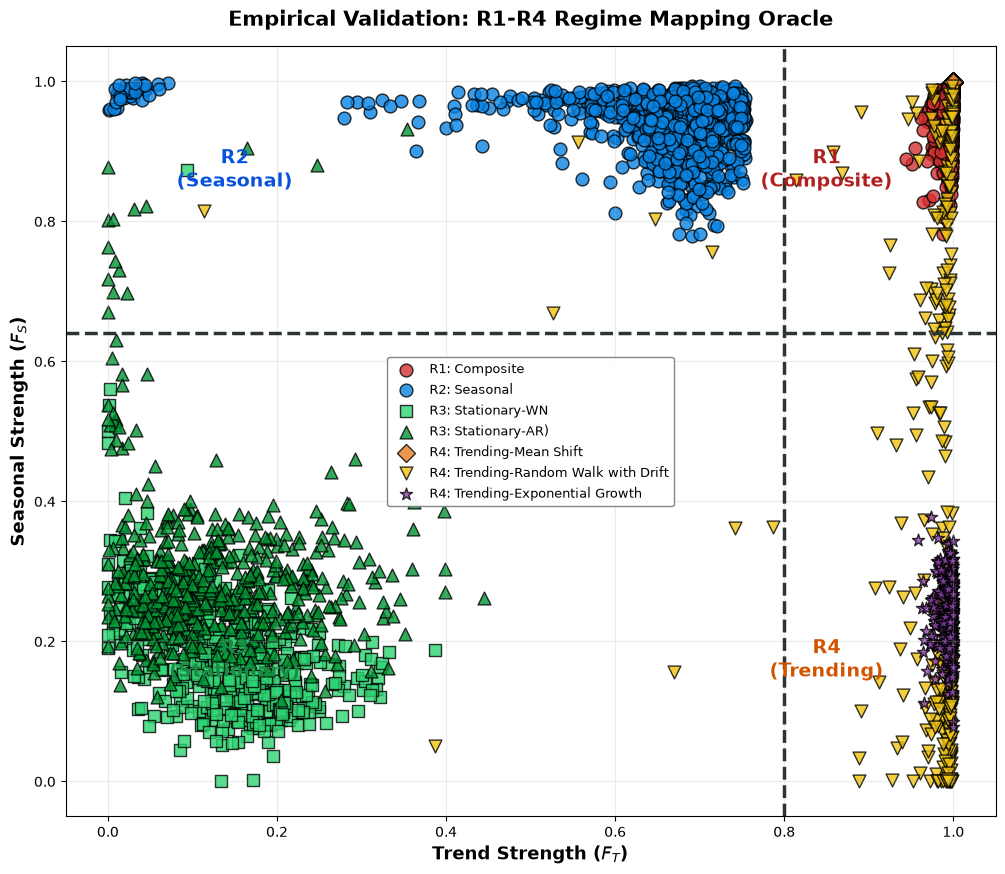


     [오라클 검증 통계 리포트 (임계치: 0.64)]
▶ R1: Composite Regime
  - 생성 패턴 예시: <ArrowStringArray>['Composite']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.994 | Mean F_S = 0.957
  - FFT 주기 추정 정확도: 76.6%
  - 사분면 매핑 성공률 : [ 1000 / 1000 ] (100.0%)
------------------------------------------------------------
▶ R2: Seasonal Regime
  - 생성 패턴 예시: <ArrowStringArray>['Seasonal']Length: 1, dtype: str
  - 평균 지표값  : Mean F_T = 0.647 | Mean F_S = 0.943
  - FFT 주기 추정 정확도: 74.9%
  - 사분면 매핑 성공률 : [ 1000 / 1000 ] (100.0%)
------------------------------------------------------------
▶ R3: Stationary Regime
  - 생성 패턴 예시: <ArrowStringArray>['Stationary_AR', 'Stationary_WN']Length: 2, dtype: str
  - 평균 지표값  : Mean F_T = 0.136 | Mean F_S = 0.240
  - 사분면 매핑 성공률 : [ 984 / 1000 ] (98.4%)
------------------------------------------------------------
▶ R4: Trending Regime
  - 생성 패턴 예시: <ArrowStringArray>['Trending_ExponentialGrowth', 'Trending_MeanShift', 'Trending_RandomWalkDrift']Length: 3, dtype: str
  - 평균 지표값  :

In [5]:
# ==========================================
# 2. 결과 시각화 (R1~R4 범례 순서 고정 및 세부 패턴 플롯팅)
# ==========================================
F_T_thr = 0.80
F_S_thr = 0.64

plt.figure(figsize=(12, 10))

# 1. 학술적 일관성을 위해 패턴별 고유 시각 세팅 테이블 정의
pattern_configs = {
    'Composite':                    {'color': '#d63031', 'marker': 'o', 'label': 'R1: Composite'},
    'Seasonal':                     {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Seasonal'},
    'Stationary_WN':                {'color': '#2ed573', 'marker': 's', 'label': 'R3: Stationary-WN'},
    'Stationary_AR':                {'color': '#009432', 'marker': '^', 'label': 'R3: Stationary-AR)'},
    'Trending_MeanShift':           {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Trending-Mean Shift'},
    'Trending_RandomWalkDrift':     {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Trending-Random Walk with Drift'},
    'Trending_ExponentialGrowth':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending-Exponential Growth'}
}

# 2. 범례 순서를 R1 -> R2 -> R3 -> R4 순으로 강제 정렬하기 위한 마스터 맵 순서 선언
legend_order = [
    'Composite',
    'Seasonal',
    'Stationary_WN',
    'Stationary_AR',
    'Trending_MeanShift',
    'Trending_RandomWalkDrift',
    'Trending_ExponentialGrowth'
]

# 3. 데이터프레임 내에 존재하는 패턴만 필터링하여 순서대로 플롯팅 (범례 순서 꼬임 원천 차단)
existing_patterns = [p for p in legend_order if p in df_exp_results['Pattern'].unique()]

for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    
    plt.scatter(group['F_T'], group['F_S'], 
                label=config['label'], color=config['color'], marker=config['marker'],
                alpha=0.8, edgecolors='k', s=85)

# 오라클 결정 가이드라인 경계선 (tau = 0.64)
plt.axvline(x=F_T_thr, color='#2d3436', linestyle='--', linewidth=2.5)
plt.axhline(y=F_S_thr, color='#2d3436', linestyle='--', linewidth=2.5)

# 사분면 텍스트 표기
plt.text(0.85, 0.85, 'R1\n(Composite)', fontsize=14, fontweight='bold', ha='center', color='#b21f1f')
plt.text(0.15, 0.85, 'R2\n(Seasonal)', fontsize=14, fontweight='bold', ha='center', color='#0652dd')
plt.text(0.15, 0.15, 'R3\n(Stationary)', fontsize=14, fontweight='bold', ha='center', color='#1b8a43')
plt.text(0.85, 0.15, 'R4\n(Trending)', fontsize=14, fontweight='bold', ha='center', color='#d35400')

plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.xlabel('Trend Strength ($F_T$)', fontsize=13, fontweight='bold')
plt.ylabel('Seasonal Strength ($F_S$)', fontsize=13, fontweight='bold')
plt.title('Empirical Validation: R1-R4 Regime Mapping Oracle', fontsize=15, fontweight='bold', pad=15)

# 범례 정중앙 위치 설정 (가독성을 위한 반투명 흰색 배경막 장착)
plt.legend(loc='center', fontsize=9.5, framealpha=0.95, facecolor='white', edgecolor='gray')
plt.grid(True, alpha=0.25)
plt.show()

# ==========================================
# 3. 오라클 분류 정확도 결산 리포트 출력
# ==========================================
print("\n" + "="*60)
print("     [오라클 검증 통계 리포트 (임계치: 0.64)]")
print("="*60)

regime_names = {'R1': 'Composite Regime', 'R2': 'Seasonal Regime', 'R3': 'Stationary Regime', 'R4': 'Trending Regime'}

total_success = 0
# 데이터셋 내의 고유 레짐 라벨을 기준으로 루프 실행
for r_label in ['R1', 'R2', 'R3', 'R4']:
    sub_df = df_exp_results[df_exp_results['True_Regime'] == r_label]
    
    # 사분면 조건문 (R1~R4 로직 반영)
    if r_label == 'R1':
        success_condition = (sub_df['F_T'] >= F_T_thr) & (sub_df['F_S'] >= F_S_thr)
    elif r_label == 'R2':
        success_condition = (sub_df['F_T'] < F_T_thr) & (sub_df['F_S'] >= F_S_thr)
    elif r_label == 'R3':
        success_condition = (sub_df['F_T'] < F_T_thr) & (sub_df['F_S'] < F_S_thr)
    elif r_label == 'R4':
        success_condition = (sub_df['F_T'] >= F_T_thr) & (sub_df['F_S'] < F_S_thr)
        
    success_count = len(sub_df[success_condition])
    total_success += success_count
    accuracy = (success_count / len(sub_df)) * 100
    
    unique_patterns = list(sub_df['Pattern'].unique())
    print(f"▶ {r_label}: {regime_names[r_label]}")
    print(f"  - 생성 패턴 예시: <ArrowStringArray>{unique_patterns}Length: {len(unique_patterns)}, dtype: str")
    print(f"  - 평균 지표값  : Mean F_T = {sub_df['F_T'].mean():.3f} | Mean F_S = {sub_df['F_S'].mean():.3f}")
    
    # 주기 매칭 검증 (R1, R2에 대해서만 추출 성과 체크)
    if r_label in ['R1', 'R2']:
        same_p_count = len(sub_df[sub_df['True_P'] == sub_df['Est_P']])
        p_match_rate = (same_p_count / len(sub_df)) * 100
        print(f"  - FFT 주기 추정 정확도: {p_match_rate:.1f}%")
        
    print(f"  - 사분면 매핑 성공률 : [ {success_count} / {len(sub_df)} ] ({accuracy:.1f}%)")
    print("-" * 60)

print(f"■ 전체 통합 오라클 라우팅 정확도: {(total_success / len(df_exp_results))*100:.2f}%")
print("="*60)

# Motivating Observations

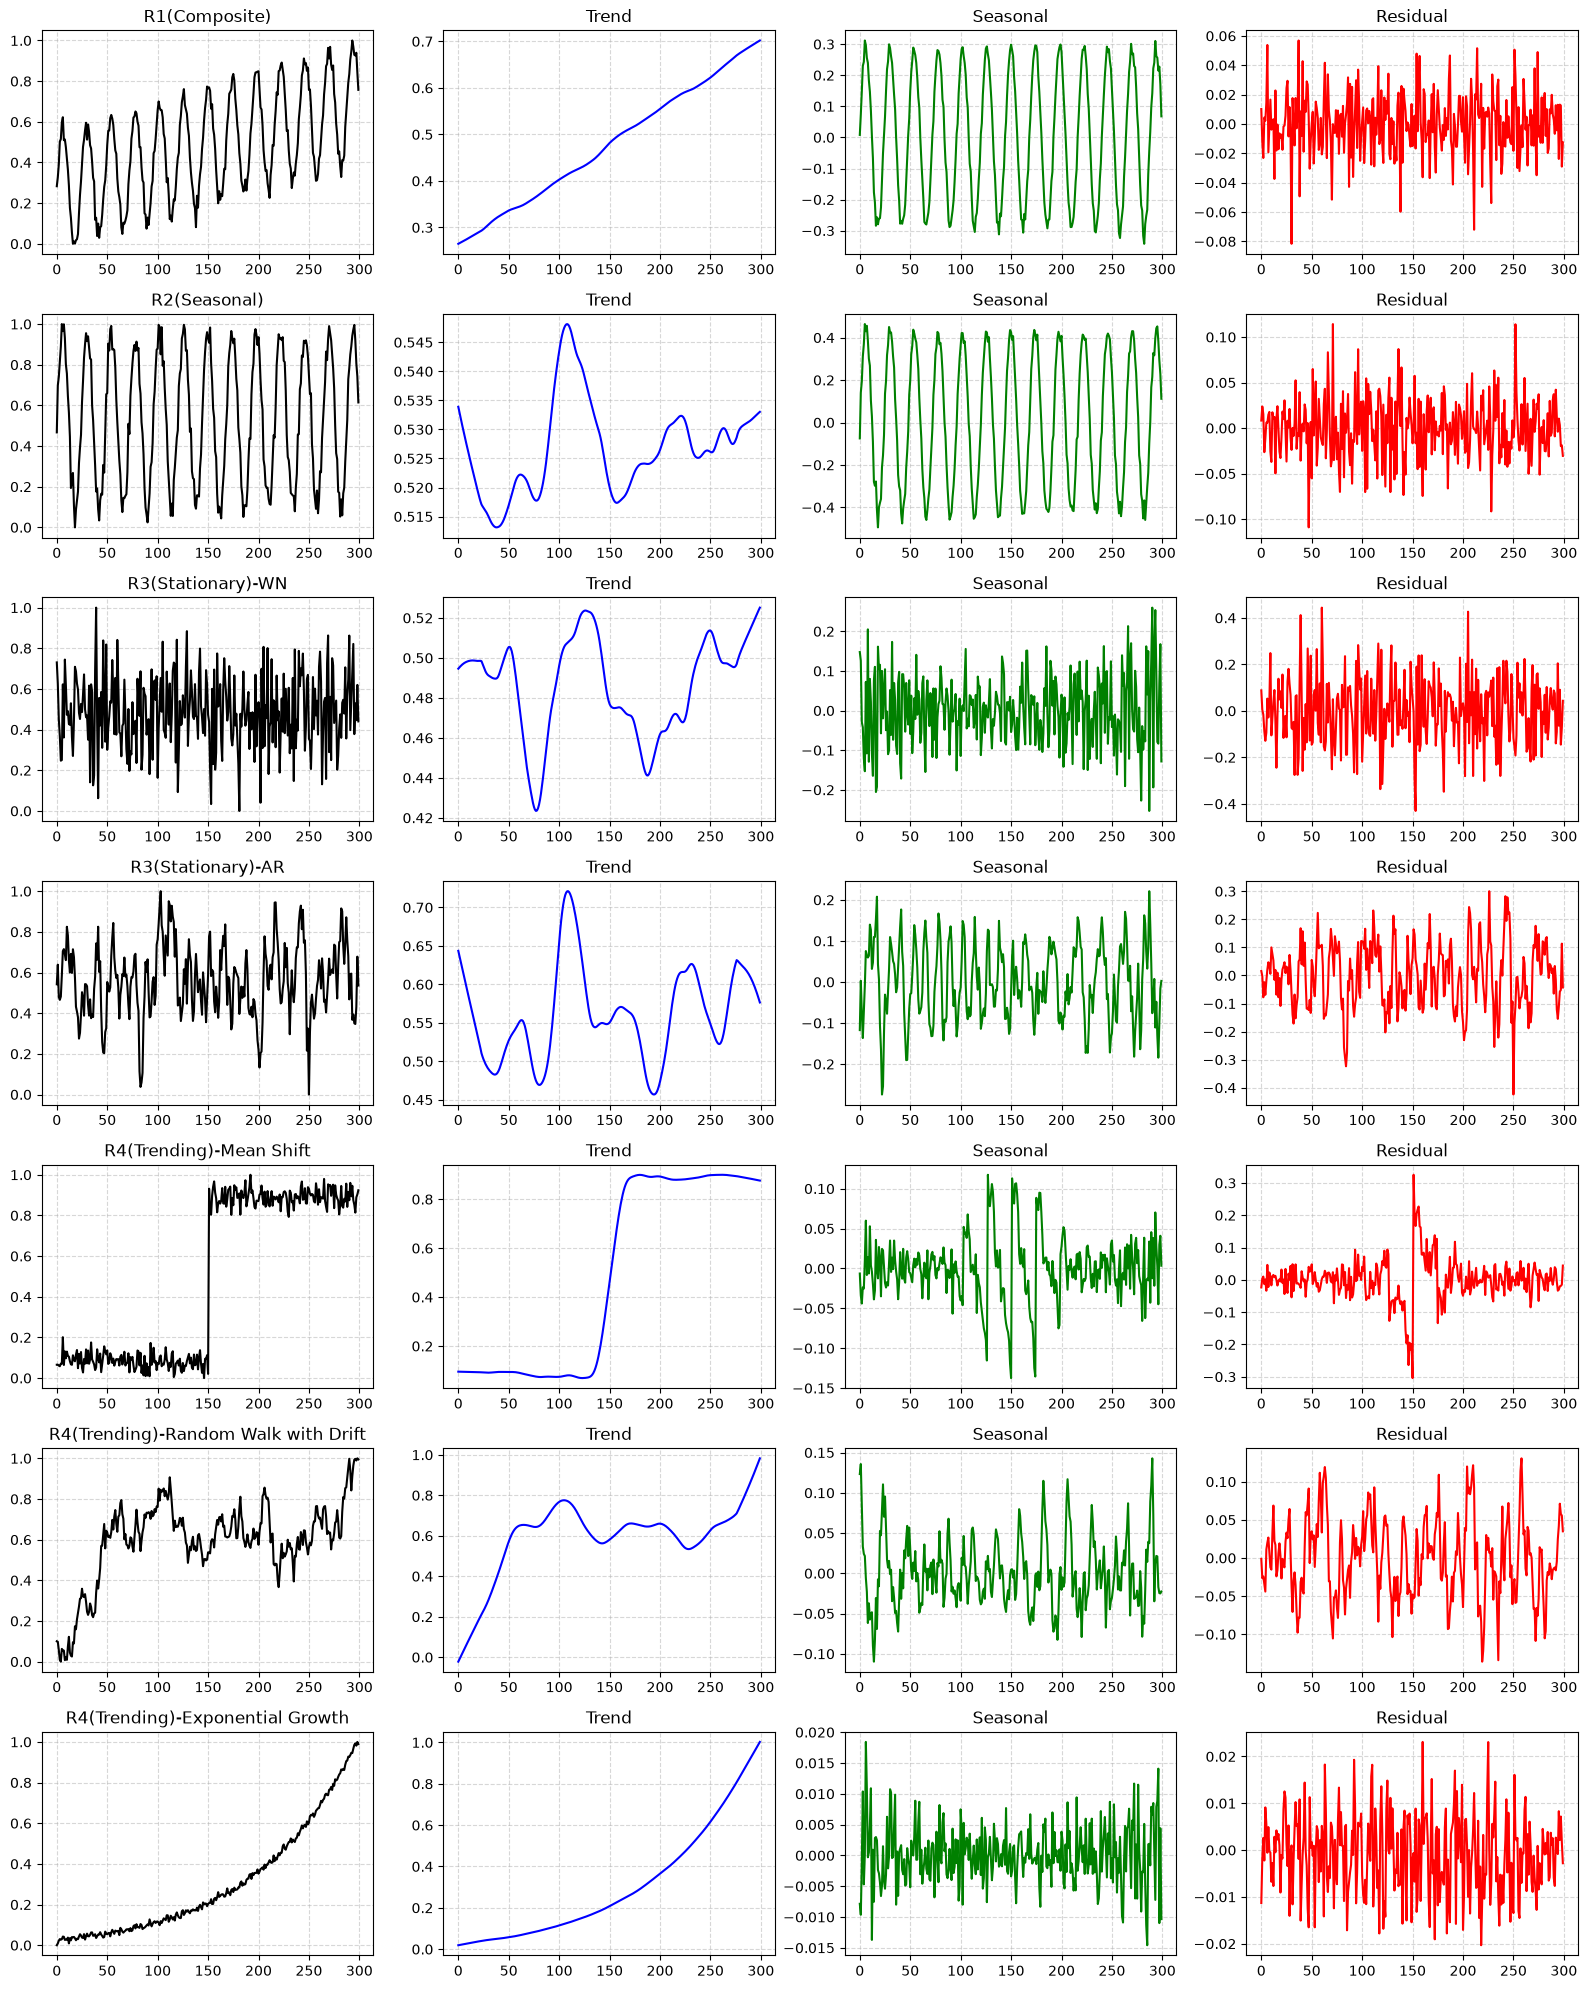

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from sklearn.preprocessing import MinMaxScaler

# 1. 7가지 레짐 생성 (이전과 동일)
def generate_regimes(n=300):
    t = np.arange(n)
    r1 = 0.05 * t + 10 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 1, n)
    r2 = 10 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 1, n)
    r3_t1 = np.random.normal(0, 1, n)
    r3_t2 = np.zeros(n)
    for i in range(1, n): r3_t2[i] = 0.8 * r3_t2[i-1] + np.random.normal(0, 1)
    r4_t1 = np.where(t > n//2, 20, 0) + np.random.normal(0, 1, n)
    r4_t2 = np.cumsum(np.random.normal(0.1, 1, n))
    r4_t3 = 5 * np.exp(0.01 * t) + np.random.normal(0, 1, n)
    return {'R1(Composite)': r1, 'R2(Seasonal)': r2, 'R3(Stationary)-WN': r3_t1, 'R3(Stationary)-AR': r3_t2, 
            'R4(Trending)-Mean Shift': r4_t1, 'R4(Trending)-Random Walk with Drift': r4_t2, 'R4(Trending)-Exponential Growth': r4_t3}

data_dict = generate_regimes()
scaler = MinMaxScaler()

# 2. STL 분해 및 전체 성분 시각화 (Min-Max Scaling 포함)
fig, axes = plt.subplots(7, 4, figsize=(16, 20))

for i, (name, data) in enumerate(data_dict.items()):
    # Min-Max Scaling 적용 (2D 배열 형태 변경 필요)
    scaled_data = scaler.fit_transform(data.reshape(-1, 1)).flatten()
    
    stl = STL(scaled_data, period=24).fit()
    
    axes[i, 0].plot(scaled_data, color='black'); axes[i, 0].set_title(f"{name}")
    axes[i, 1].plot(stl.trend, color='blue'); axes[i, 1].set_title("Trend")
    axes[i, 2].plot(stl.seasonal, color='green'); axes[i, 2].set_title("Seasonal")
    axes[i, 3].plot(stl.resid, color='red'); axes[i, 3].set_title("Residual")
    
    for j in range(4): axes[i, j].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# # Illustrative Example: EMD-IMF

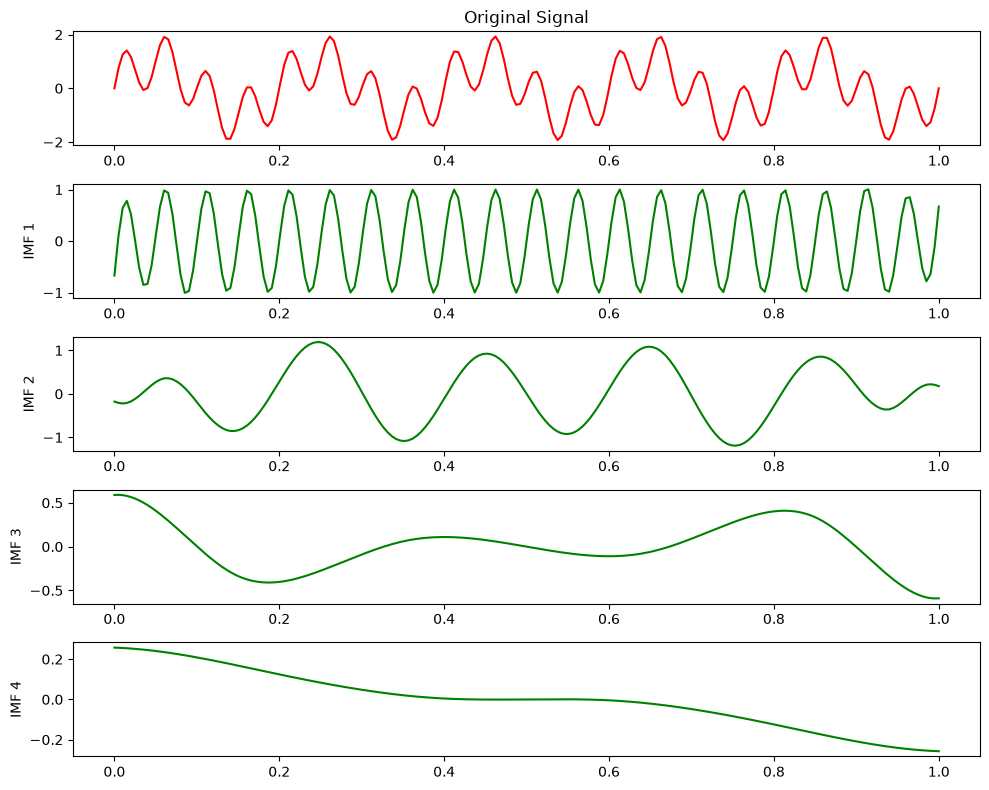

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from PyEMD import EMD

# 1. 샘플 데이터 생성
t = np.linspace(0, 1, 200)
s = np.sin(2 * np.pi * 5 * t) + np.sin(2 * np.pi * 20 * t)  # 5Hz와 20Hz 신호 혼합

# 2. EMD 객체 생성 및 분해
emd = EMD()
imfs = emd(s) # IMF들이 담긴 배열 반환

# 3. 결과 시각화
n_imfs = imfs.shape[0]
plt.figure(figsize=(10, 8))
plt.subplot(n_imfs + 1, 1, 1)
plt.plot(t, s, 'r')
plt.title("Original Signal")

for i in range(n_imfs):
    plt.subplot(n_imfs + 1, 1, i + 2)
    plt.plot(t, imfs[i], 'g')
    plt.ylabel(f"IMF {i+1}")

plt.tight_layout()
plt.show()

# Illustrative Example: STL-EMD로 Mean Shift 데이터 분해해서 T, S, I, R 성분 시각화

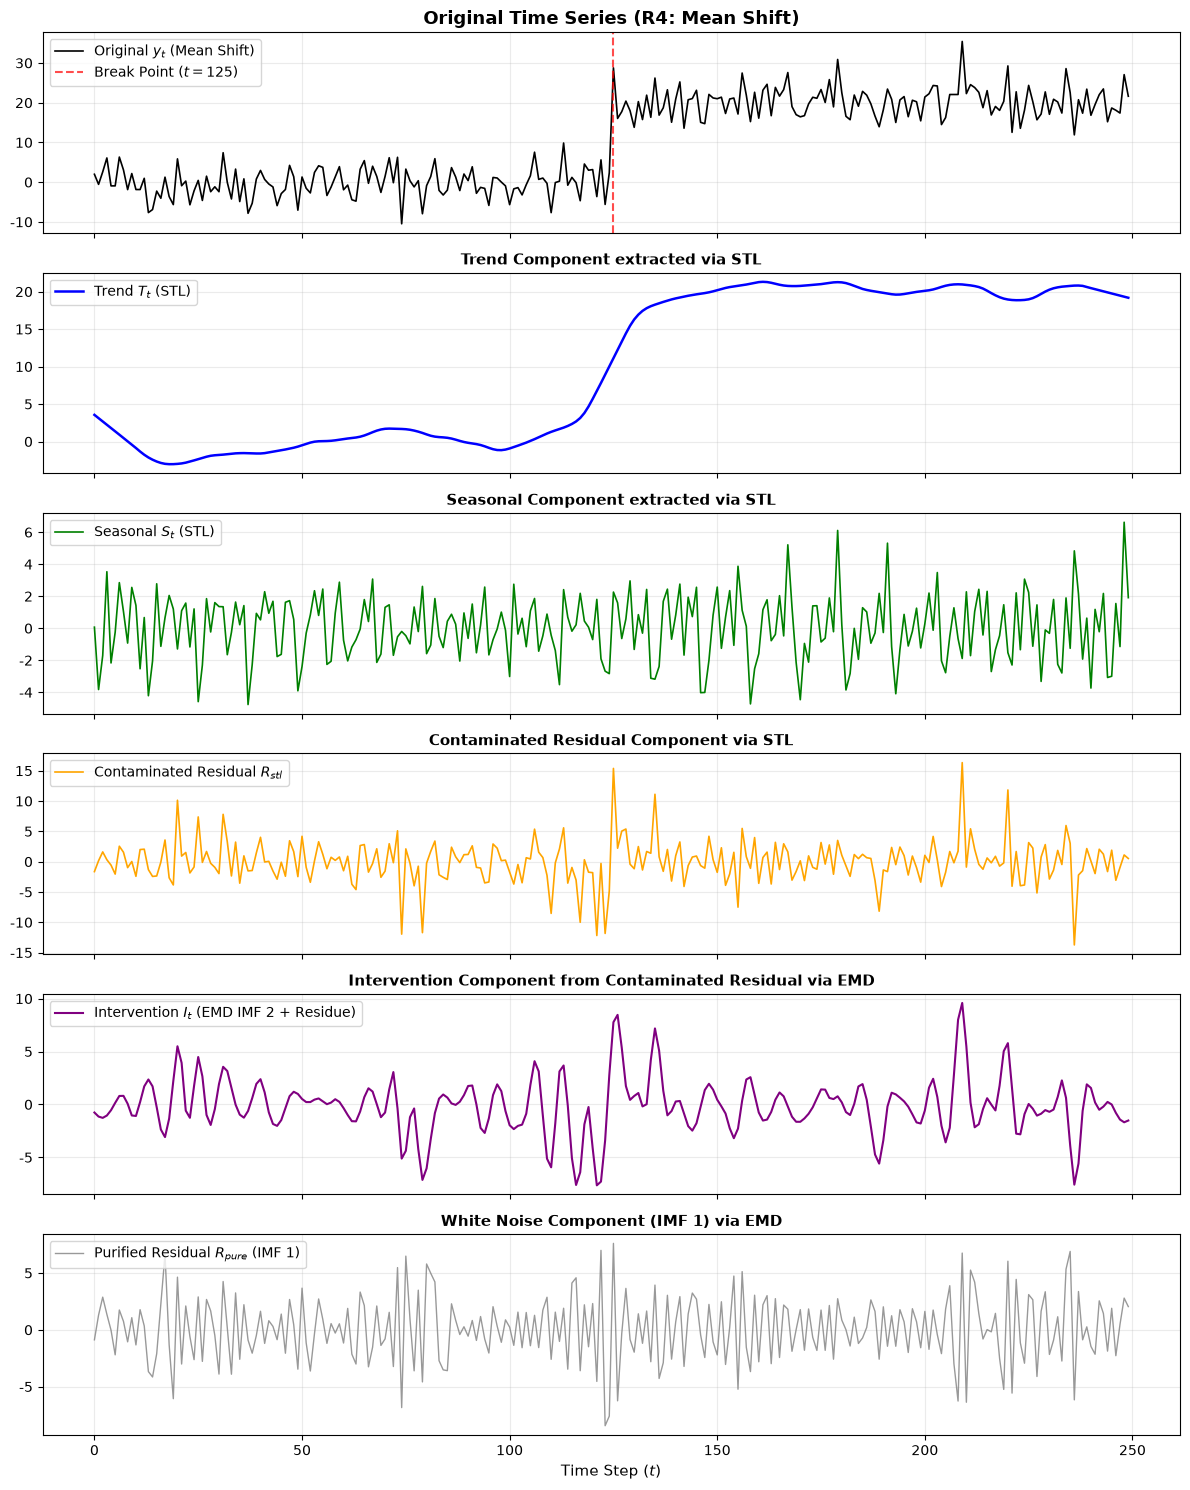

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL
from PyEMD import EMD

# 1. 연구용 샘플 데이터 생성 (R4 레짐 - Mean Shift 유형 고도화)
np.random.seed(42)
length = 250
noise_std = 4.0
bp_val = length // 2  # t=125 시점에 구조적 단절 발생

# 기저 생성 기전 (DGP): 순수 백색 잡음에 t=125부터 명확한 계단식 수직 점프(Mean Shift) 주입
pure_wn = np.random.normal(0, noise_std, length)
underlying_trend = np.zeros(length)
underlying_trend[bp_val:] = 20.0  # 강력한 개입 Shock 반영

q4_series = underlying_trend + pure_wn

# 2. 1단계: 전통적 STL 분해 수행
estimated_period = 12
stl = STL(q4_series, period=estimated_period, robust=True).fit()
T_stl = stl.trend
S_stl = stl.seasonal
R_stl = stl.resid  # 오염된 잔차 (의사 계절성 및 쇼크 변동성 누출)

# 3. 2단계: EMD 기반 잔차 공간 재분해 (연구자님의 IMF_1 격리 로직 적용)
emd = EMD()
imfs = emd.emd(R_stl)

# [수정 핵심 수리 로직]: 최고주파 성분인 IMF 1을 순수 백색 잡음으로 정의
if len(imfs) > 1:
    R_pure = imfs[0]                   # IMF 1 -> 순수 백색 잡음 (White Noise) 격리
    I_emd = np.sum(imfs[1:], axis=0)   # IMF 2 ~ 최종 Residue의 합 -> 결정론적 개입 충격 성분 ($I_t$)
else:
    R_pure = R_stl
    I_emd = np.zeros(length)

# 4. 학술 장표용 6단 구성 시각화 (Original -> T -> S -> R_stl -> I -> Pure R)
fig, axes = plt.subplots(6, 1, figsize=(12, 15), sharex=True)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# [Plot 1] 원본 시계열 데이터
axes[0].plot(q4_series, color='black', linewidth=1.2, label='Original $y_t$ (Mean Shift)')
axes[0].axvline(x=bp_val, color='red', linestyle='--', alpha=0.7, label='Break Point ($t=125$)')
axes[0].set_title('Original Time Series (R4: Mean Shift)', fontsize=13, weight='bold')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.25)

# [Plot 2] STL 추세 성분 (S자 형태로 왜곡된 트렌드)
axes[1].plot(T_stl, color='blue', linewidth=1.8, label='Trend $T_t$ (STL)')
axes[1].set_title('Trend Component extracted via STL', fontsize=11, weight='bold')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.25)

# [Plot 3] STL 가짜 계절성 (단절점 부근에서 억지로 짜내진 주기성 누출)
axes[2].plot(S_stl, color='green', linewidth=1.2, label='Seasonal $S_t$ (STL)')
axes[2].set_title('Seasonal Component extracted via STL', fontsize=11, weight='bold')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.25)

# [Plot 4] 1단계 결과물: 오염되고 왜곡된 STL 잔차
axes[3].plot(R_stl, color='orange', linewidth=1.2, label='Contaminated Residual $R_{stl}$')
axes[3].set_title('Contaminated Residual Component via STL', fontsize=11, weight='bold')
axes[3].legend(loc='upper left')
axes[3].grid(True, alpha=0.25)

# [Plot 5] 2단계 혁신: 잔차 공간에서 순수 구조적 충격만 복원한 개입 성분
axes[4].plot(I_emd, color='purple', linewidth=1.5, label='Intervention $I_t$ (EMD IMF 2 + Residue)')
#axes[4].axvline(x=bp_val, color='red', linestyle='--', alpha=0.5)
axes[4].set_title('Intervention Component from Contaminated Residual via EMD', fontsize=11, weight='bold')
axes[4].legend(loc='upper left')
axes[4].grid(True, alpha=0.25)

# [Plot 6] 2단계 혁신: 정제된 순수 백색 잡음 (IMF 1)
axes[5].plot(R_pure, color='gray', linewidth=1.0, alpha=0.8, label='Purified Residual $R_{pure}$ (IMF 1)')
axes[5].set_title('White Noise Component (IMF 1) via EMD', fontsize=11, weight='bold')
axes[5].legend(loc='upper left')
axes[5].grid(True, alpha=0.25)
axes[5].set_xlabel('Time Step ($t$)', fontsize=11)

plt.tight_layout()
plt.show()

# STL-EMD based DATC

In [5]:
df_exp_results = generate_synthetic_dataset(num_samples_per_regime=1000, len_series=500, dec_method='stl_emd')
df_exp_results.to_csv('../../results/temp/0706_Per1000_Len500_StlEmd_synthetic_dataset.csv', index=False)

🔹 Generating synthetic dataset with 1000 samples per regime, each of length 500 with stl_emd method
💡 Generating sample 1/1000 for each regime...
ExponentialGrowth series generated. Estimated period: 24, F_T: 0.9815, F_S: 0.3923, F_I: 0.4154
💡 Generating sample 2/1000 for each regime...
💡 Generating sample 3/1000 for each regime...
💡 Generating sample 4/1000 for each regime...
ExponentialGrowth series generated. Estimated period: 24, F_T: 0.9998, F_S: 0.3826, F_I: 0.4440
💡 Generating sample 5/1000 for each regime...
💡 Generating sample 6/1000 for each regime...
💡 Generating sample 7/1000 for each regime...
ExponentialGrowth series generated. Estimated period: 24, F_T: 0.9978, F_S: 0.3264, F_I: 0.3866
💡 Generating sample 8/1000 for each regime...
💡 Generating sample 9/1000 for each regime...
💡 Generating sample 10/1000 for each regime...
💡 Generating sample 11/1000 for each regime...
💡 Generating sample 12/1000 for each regime...
💡 Generating sample 13/1000 for each regime...
💡 Generati

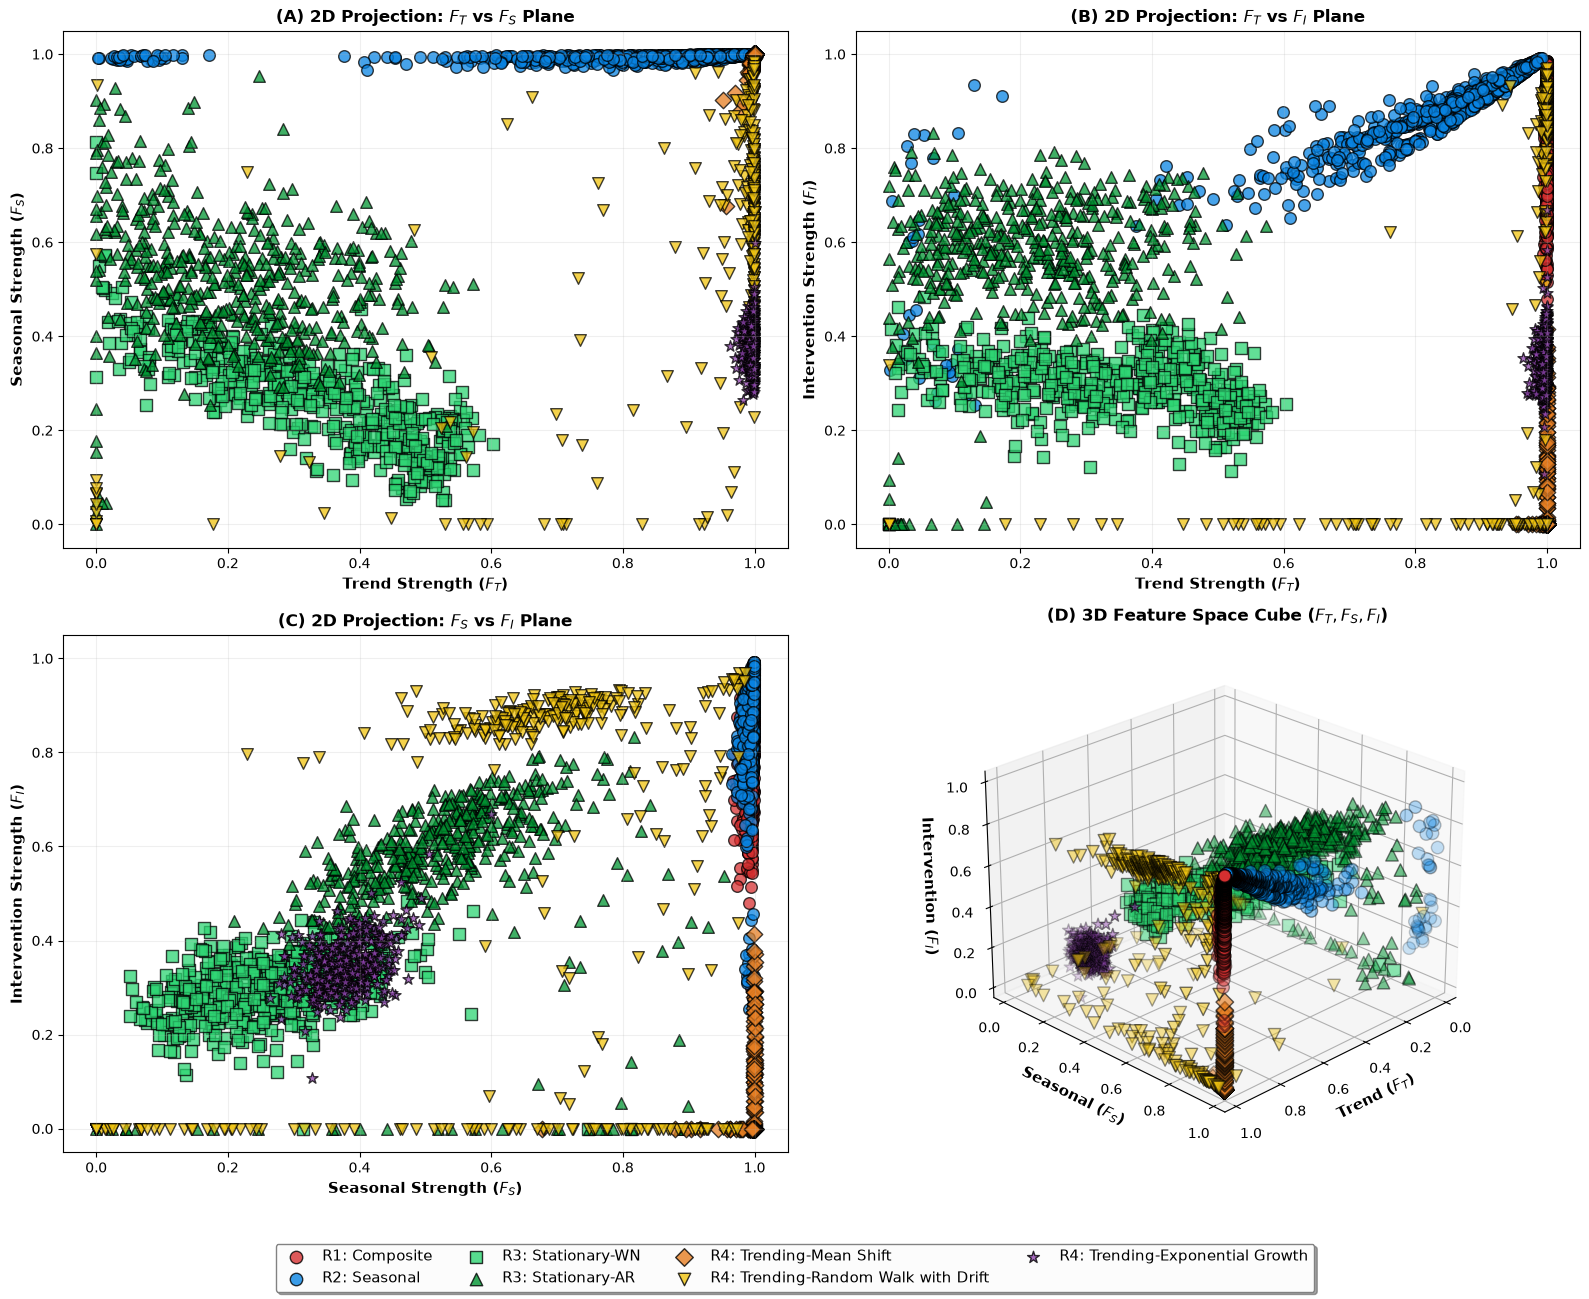

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3차원 플롯 활성화

# 학술 장표용 2x2 Grid Figure 선언 (상단 2D 평면 3개, 하단 3D 큐브 공간 1개 배치)
fig = plt.figure(figsize=(16, 14))
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

# ==========================================
# 1. 고유 시각 세팅 테이블 및 범례 고정 순서 선언
# ==========================================
pattern_configs = {
    'Composite':                    {'color': '#d63031', 'marker': 'o', 'label': 'R1: Composite'},
    'Seasonal':                     {'color': '#0984e3', 'marker': 'o', 'label': 'R2: Seasonal'},
    'Stationary_WN':                {'color': '#2ed573', 'marker': 's', 'label': 'R3: Stationary-WN'},
    'Stationary_AR':                {'color': '#009432', 'marker': '^', 'label': 'R3: Stationary-AR'},
    'Trending_MeanShift':           {'color': '#e67e22', 'marker': 'D', 'label': 'R4: Trending-Mean Shift'},
    'Trending_RandomWalkDrift':     {'color': '#f1c40f', 'marker': 'v', 'label': 'R4: Trending-Random Walk with Drift'},
    'Trending_ExponentialGrowth':   {'color': '#8e44ad', 'marker': '*', 'label': 'R4: Trending-Exponential Growth'}
}

legend_order = [
    'Composite', 'Seasonal', 'Stationary_WN', 'Stationary_AR',
    'Trending_MeanShift', 'Trending_RandomWalkDrift', 'Trending_ExponentialGrowth'
]
existing_patterns = [p for p in legend_order if p in df_exp_results['Pattern'].unique()]

# ==========================================
# 2. 서브플롯 1: (F_T, F_S) 평면 사영
# ==========================================
ax1 = fig.add_subplot(2, 2, 1)
for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    ax1.scatter(group['F_T'], group['F_S'], color=config['color'], marker=config['marker'],
                alpha=0.75, edgecolors='k', s=70)
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.set_xlabel('Trend Strength ($F_T$)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Seasonal Strength ($F_S$)', fontsize=11, fontweight='bold')
ax1.set_title('(A) 2D Projection: $F_T$ vs $F_S$ Plane', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.2)

# ==========================================
# 3. 서브플롯 2: (F_T, F_I) 평면 사영
# ==========================================
ax2 = fig.add_subplot(2, 2, 2)
for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    ax2.scatter(group['F_T'], group['F_I'], color=config['color'], marker=config['marker'],
                alpha=0.75, edgecolors='k', s=70)
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.set_xlabel('Trend Strength ($F_T$)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Intervention Strength ($F_I$)', fontsize=11, fontweight='bold')
ax2.set_title('(B) 2D Projection: $F_T$ vs $F_I$ Plane', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.2)

# ==========================================
# 4. 서브플롯 3: (F_S, F_I) 평면 사영
# ==========================================
ax3 = fig.add_subplot(2, 2, 3)
for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    ax3.scatter(group['F_S'], group['F_I'], color=config['color'], marker=config['marker'],
                alpha=0.75, edgecolors='k', s=70)
ax3.set_xlim(-0.05, 1.05)
ax3.set_ylim(-0.05, 1.05)
ax3.set_xlabel('Seasonal Strength ($F_S$)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Intervention Strength ($F_I$)', fontsize=11, fontweight='bold')
ax3.set_title('(C) 2D Projection: $F_S$ vs $F_I$ Plane', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.2)

# ==========================================
# 5. 서브플롯 4: (F_T, F_S, F_I) 3차원 하이브리드 오라클 큐브 공간
# ==========================================
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x', 'label': pattern_label})
    # 3D 스캐터 플롯 수행
    ax4.scatter(group['F_T'], group['F_S'], group['F_I'], 
                color=config['color'], marker=config['marker'],
                label=config['label'], alpha=0.8, edgecolors='k', s=80)

ax4.set_xlim(-0.05, 1.05)
ax4.set_ylim(-0.05, 1.05)
ax4.set_zlim(-0.05, 1.05)
ax4.set_xlabel('Trend ($F_T$)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Seasonal ($F_S$)', fontsize=11, fontweight='bold')
ax4.set_zlabel('Intervention ($F_I$)', fontsize=11, fontweight='bold')
ax4.set_title('(D) 3D Feature Space Cube ($F_T, F_S, F_I$)', fontsize=12, fontweight='bold', pad=10)

# 시각적 가독성을 높이기 위해 3D 뷰 포트 각도 조정 (Azimuth & Elevation)
ax4.view_init(elev=25, azim=45)
ax4.grid(True, alpha=0.15)

# ==========================================
# 6. 전체 통합 범례 및 레이아웃 출력 정돈
# ==========================================
# 플롯 전체를 관통하는 통합 대형 타이틀 선언
#fig.suptitle('Geometric Isolation Analysis in Hybrid STL-EMD Multi-Dimensional Gating Space', 
#             fontsize=16, fontweight='bold', y=0.96)

# 3D 축 플롯(ax4)의 고정 순서 라벨들을 취합하여 단 하나의 마스터 레전드 박스로 정중앙 하단 혹은 우측 배치
handles, labels = ax4.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=10.5, 
           framealpha=0.98, facecolor='white', edgecolor='gray', shadow=True)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.show()

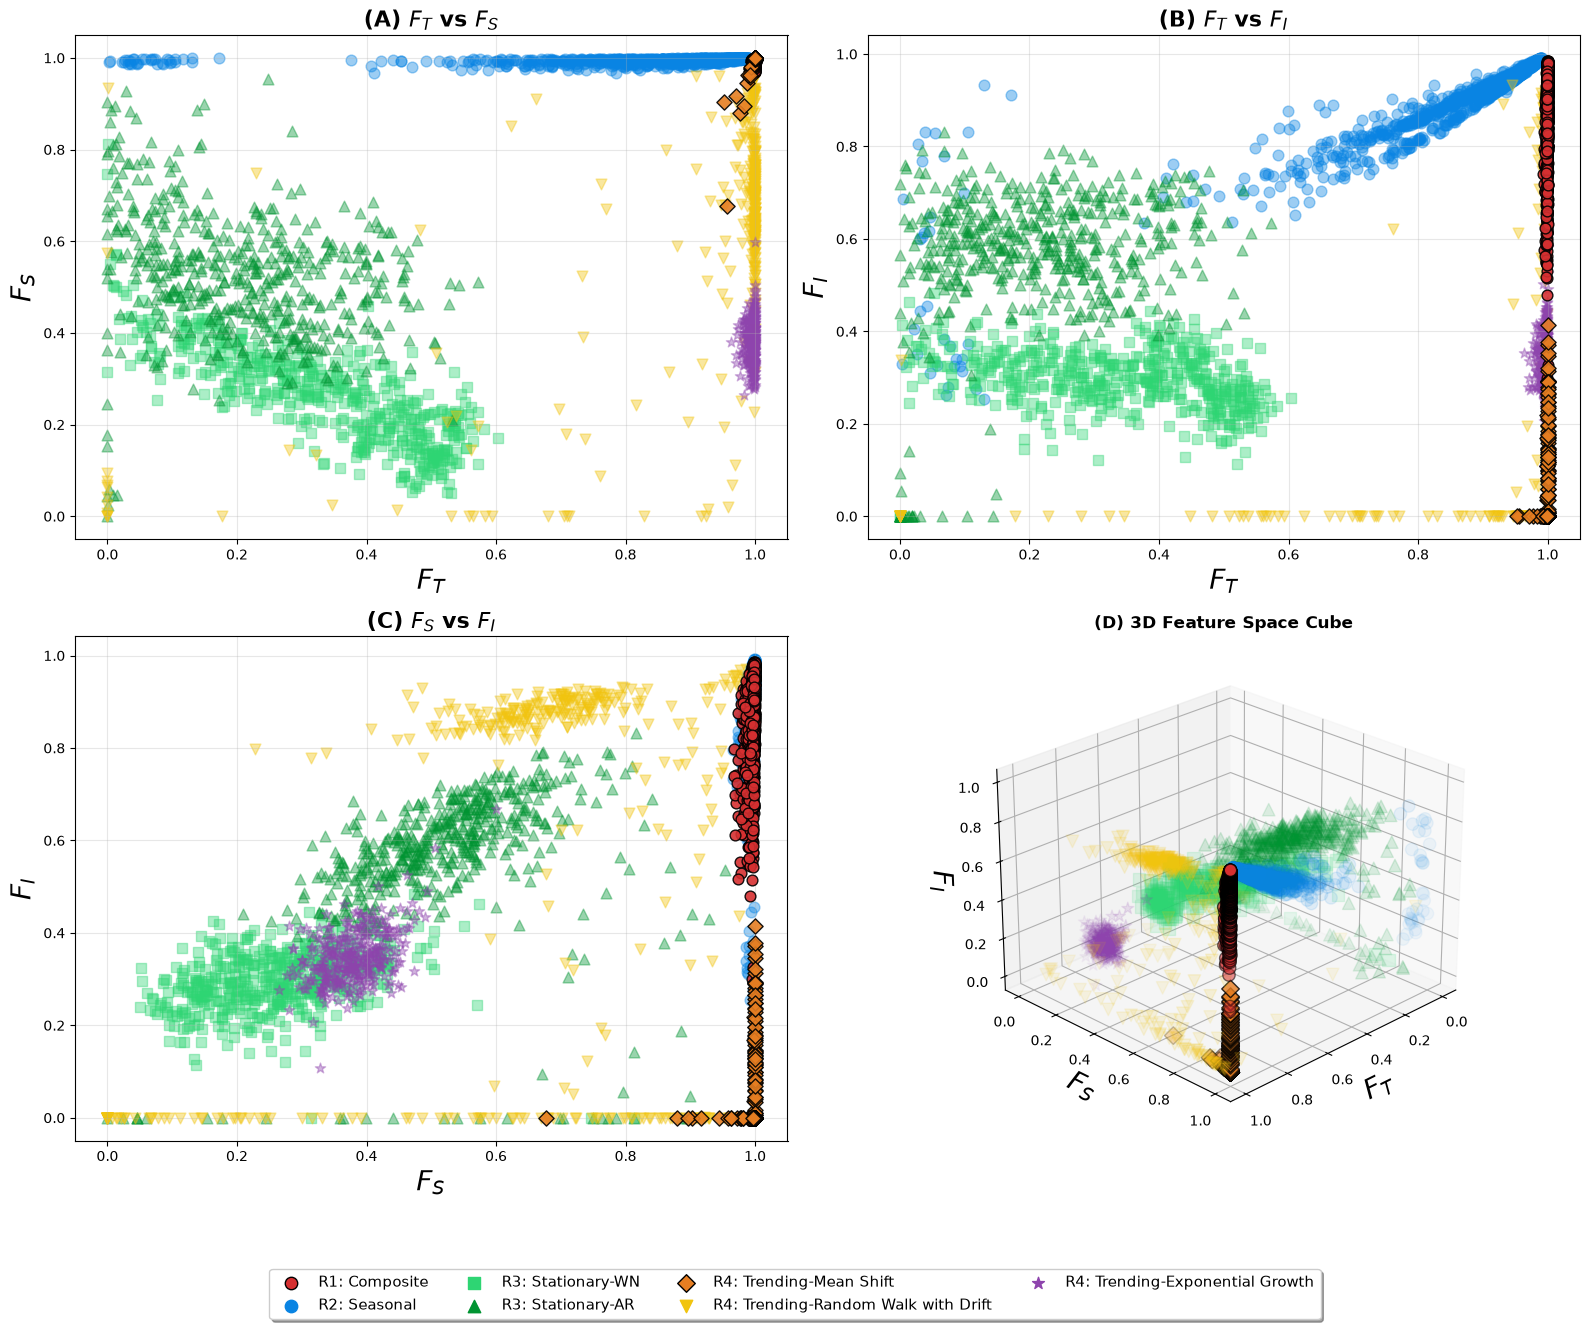

In [24]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D

# 타겟 패턴 정의 (강조할 그룹)
target_patterns = ['Composite', 'Trending_MeanShift']

def get_style(pattern_label):
    # 타겟은 선명하게, 나머지는 투명하게(0.05) 설정
    if pattern_label in target_patterns:
        return {'alpha': 0.9, 'edgecolors': 'k', 'zorder': 10}
    else:
        return {'alpha': 0.4, 'edgecolors': None, 'zorder': 1}

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2)

# 각 서브플롯 정보 정의 (순서: 2D 3개 -> 3D 1개)
plot_specs = [
    (gs[0, 0], 'F_T', 'F_S', '(A) $F_T$ vs $F_S$'),
    (gs[0, 1], 'F_T', 'F_I', '(B) $F_T$ vs $F_I$'),
    (gs[1, 0], 'F_S', 'F_I', '(C) $F_S$ vs $F_I$')
]

# 1. 2D 서브플롯 생성
for pos, x_col, y_col, title in plot_specs:
    ax = fig.add_subplot(pos)
    for pattern_label in existing_patterns:
        group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
        config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x'})
        style = get_style(pattern_label)
        
        ax.scatter(group[x_col], group[y_col], color=config['color'], 
                   marker=config['marker'], alpha=style['alpha'], 
                   edgecolors=style['edgecolors'], s=60, zorder=style['zorder'])
    
    #ax.set_xlabel(x_col.replace('_', ' '), fontsize=11, fontweight='bold')
    #ax.set_ylabel(y_col.replace('_', ' '), fontsize=11, fontweight='bold')
    ax.set_xlabel(f'${x_col}$', fontsize=20, fontweight='bold')
    ax.set_ylabel(f'${y_col}$', fontsize=20, fontweight='bold')
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)

# 2. 3D 서브플롯 생성
ax_3d = fig.add_subplot(gs[1, 1], projection='3d')
for pattern_label in existing_patterns:
    group = df_exp_results[df_exp_results['Pattern'] == pattern_label]
    config = pattern_configs.get(pattern_label, {'color': '#7f8c8d', 'marker': 'x'})
    style = get_style(pattern_label)
    
    # 3D 스캐터 플롯 (라벨을 위해 플롯 시도)
    ax_3d.scatter(group['F_T'], group['F_S'], group['F_I'], 
                  color=config['color'], marker=config['marker'],
                  label=config['label'], alpha=style['alpha'], 
                  edgecolors=style['edgecolors'], s=80, zorder=style['zorder'])

ax_3d.set_xlabel('$F_T$', fontsize=20, fontweight='bold')
ax_3d.set_ylabel('$F_S$', fontsize=20, fontweight='bold')
ax_3d.set_zlabel('$F_I$', fontsize=20, fontweight='bold')
ax_3d.set_title('(D) 3D Feature Space Cube', fontsize=12, fontweight='bold')
ax_3d.view_init(elev=25, azim=45)

# 3. 범례 설정 (범례 아이콘의 투명도를 강제로 1.0으로 고정)
handles, labels = ax_3d.get_legend_handles_labels()
legend = fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=11, 
                    frameon=True, shadow=True)

for lh in legend.legend_handles:
    lh.set_alpha(1.0)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()